# DL_03 연습문제 - 신경망

활성화 함수, 행렬곱, 3층 신경망 forward, softmax 등을 다룹니다.

### Q1. 활성화 함수 5종 그래프
x = `np.arange(-5, 5, 0.01)` 에 대해

- step
- sigmoid
- tanh
- softplus
- ReLU

를 한 그림에 그리세요. (legend 필수)

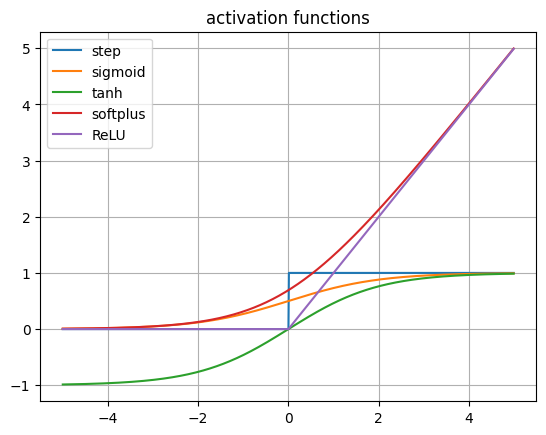

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-5, 5, 0.01)

# TODO: 5개 함수 정의 후 plt.plot
a = 1
def step(x): return np.where(x >=0, 1,0)
def sigmoid(x): return (1/(1+np.exp(-a*x)))
def tanh(x): return (2/(1+np.exp(-a*x))-1)
def softplus(x): return np.log(1+np.exp(a*x))
def ReLU(x): return np.maximum(0,x)
for i in [step,sigmoid,tanh,softplus,ReLU]:
    plt.plot(x, i(x), label = i.__name__)

plt.grid(True ); plt.title('activation functions'); plt.legend(); plt.show()

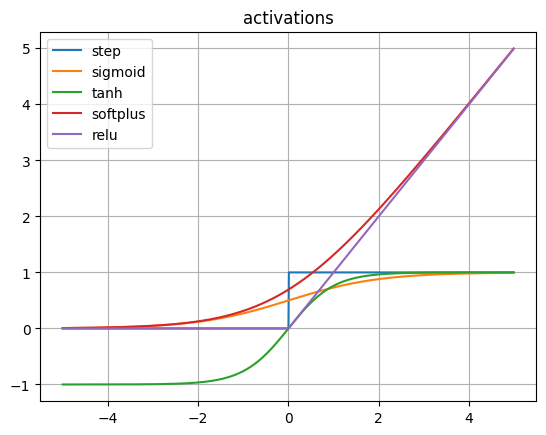

In [8]:
def step(x):     return np.where(x >= 0, 1, 0)
def sigmoid(x):  return 1 / (1 + np.exp(-x))
def tanh(x):     return 2 / (1 + np.exp(-2*x)) - 1
def softplus(x): return np.log(1 + np.exp(x))
def relu(x):     return np.maximum(0, x)

for f in [step, sigmoid, tanh, softplus, relu]:
    plt.plot(x, f(x), label=f.__name__)
plt.legend(); plt.grid(True); plt.title('activations'); plt.show()

### Q2. 시그모이드의 a값 변화 (step과의 관계)
$\sigma(x) = \dfrac{1}{1+e^{-ax}}$ 에서 a를 작은 값부터 큰 값까지 여러 개 바꿔가며 그리고, **step function** 도 같이 그려서 'a가 커질수록 step과 비슷해진다'는 것을 확인하세요.

<details><summary>힌트</summary>

a 후보: [0.5, 1, 5, 10, 100]  
step은 `np.where(x>=0, 1, 0)`
</details>

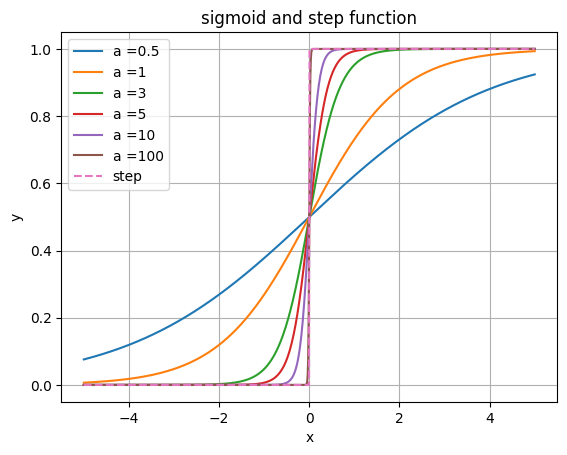

In [16]:
x = np.linspace(-5, 5, 1000)

def sigmoid_a(x, a):
    # TODO
    return 1/(1+np.exp(-a*x))

# TODO: for a in [...]: plt.plot, 그리고 step도 추가
for a in [0.5,1,3,5,10,100]:
    plt.plot(x, sigmoid_a(x, a), label = f'a ={a}')
plt.plot(x, np.where(x>=0,1,0), label = 'step', linestyle = '--')
plt.ylabel('y'); plt.xlabel('x'); plt.grid(True); plt.title('sigmoid and step function'); plt.legend(); plt.show()


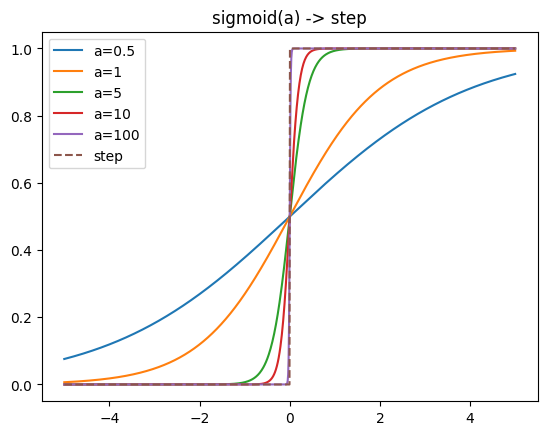

In [13]:
def sigmoid_a(x, a):
    return 1 / (1 + np.exp(-a*x))

for a in [0.5, 1, 5, 10, 100]:
    plt.plot(x, sigmoid_a(x, a), label=f'a={a}')
plt.plot(x, np.where(x>=0, 1, 0), '--', label='step')
plt.legend(); plt.title('sigmoid(a) -> step'); plt.show()

### Q3. 계단함수 두 가지 구현 - 어디서 에러나는가? (★)
교재 3.2.2 문제. 다음 두 step 함수에 대해

- `step1(x)` 에 스칼라가 아닌 배열을 넣으면 어떤 에러가 나는가? **이유까지** 설명.
- `step2(x)` 는 왜 배열에서도 잘 동작하는가?

In [22]:
def step1(x):
    if x >= 0: return 1
    else: return 0

def step2(x):
    return (x > 0).astype(np.int32)

def step3(x):
    return (x > 0)



x1 = np.array([-1.0])
x2 = np.array([-1.0, 1.0, 2.0])

print('step1(x1) :', step1(x1))   # OK (원소 1개)
print('step2(x2) :', step2(x2))   # OK (브로드캐스트)
print('step2(x1) :', step2(x1))   # OK (브로드캐스트)
print('step2(x2) :', step2(x2))
# print('step1(x2):', step1(x2))  # 주석 풀고 ValueError 확인

step1(x1) : 0
step2(x2) : [0 1 1]
step2(x1) : [0]
step2(x2) : [0 1 1]


<details><summary>정답</summary>

- `x2 >= 0` 의 결과는 `array([False, True, True])` 와 같이 **여러 원소를 가진 bool 배열**.
- 파이썬 `if` 는 단일 bool만 받으므로 `ValueError: The truth value of an array with more than one element is ambiguous` 발생.
- `step2`는 `x > 0` 의 결과 bool 배열을 그대로 `astype(int)` 로 바꾸기 때문에 원소별 처리가 가능.
</details>

### Q4. 행렬곱과 신경망
입력 x = [1,2], 가중치 W = [[1,2,3],[4,5,6]] 일 때

- y = x · W 를 직접 계산하고 shape 확인.
- `np.dot(W, x)` 는 왜 에러? 어떻게 하면 동작하는가?

In [ ]:
import numpy as np

x = np.array([1,2])               # (2,)
W = np.array([[1,2,3],[4,5,6]])   # (2,3)

y = np.dot(x, W)
print('y =', y, 'shape =', y.shape)   # (3,)

# np.dot(W, x) 는 (2,3)@(2,) -> 안맞음. W.T @ x 로 해야 (3,2)@(2,) -> (3,)
print('W.T @ x =', np.dot(W.T, x))

y = [ 9 12 15] shape = (3,)
W.T @ x = [ 9 12 15]


### Q5. 벡터 norm & cosine similarity
1. 벡터 v = [3,4]의 L2 norm을 (a) 직접 구현, (b) NumPy 함수로 두 가지 방법으로 구하세요.
2. 벡터 a=[1,2,3], b=[2,3,6] 의 cosine similarity를 직접 구현.

<details><summary>힌트</summary>

L2 norm: $\sqrt{\sum x_i^2}$, NumPy는 `np.linalg.norm(v)`  
cosine similarity: $\dfrac{a \cdot b}{\|a\|\|b\|}$ — 분자는 `np.dot`, 분모는 `np.linalg.norm`
</details>

In [ ]:
import math
v = np.array([3, 4])

def l2_norm(v):
    # TODO
    return 

def cos_sim(a, b):
    # TODO
    pass

In [ ]:
def l2_norm(v):
    return math.sqrt(sum(x**2 for x in v))

print('manual :', l2_norm(v))
print('numpy  :', np.linalg.norm(v))

a = np.array([1,2,3]); b = np.array([2,3,6])
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print('cos_sim :', cos_sim(a, b))

### Q6. 3층 신경망 forward
구조: 입력(2) → 은닉1(3, sigmoid) → 은닉2(2, sigmoid) → 출력(2, 항등)

- 입력 x = [1.0, 0.5]
- 가중치/편향은 아래 값 그대로 사용.

```
W1 = [[0.1,0.3,0.5],[0.2,0.4,0.6]],   b1 = [0.1,0.2,0.3]
W2 = [[0.1,0.4],[0.2,0.5],[0.3,0.6]], b2 = [0.1,0.2]
W3 = [[0.1,0.3],[0.2,0.4]],           b3 = [0.1,0.2]
```

In [ ]:
def sigmoid(x): return 1/(1+np.exp(-x))
def identity(x): return x

x = np.array([1.0, 0.5])
W1 = np.array([[0.1,0.3,0.5],[0.2,0.4,0.6]]); b1 = np.array([0.1,0.2,0.3])
W2 = np.array([[0.1,0.4],[0.2,0.5],[0.3,0.6]]); b2 = np.array([0.1,0.2])
W3 = np.array([[0.1,0.3],[0.2,0.4]]);           b3 = np.array([0.1,0.2])

# TODO: z1, z2, y 구하기

In [ ]:
z1 = sigmoid(np.dot(x, W1) + b1)
z2 = sigmoid(np.dot(z1, W2) + b2)
y  = identity(np.dot(z2, W3) + b3)
print('z1 :', z1)
print('z2 :', z2)
print('y  :', y)

### Q7. softmax (오버플로우 방지) ★ 시험 출제
1. a = [1010, 1000, 990] 에 대해 **그냥** softmax를 계산하면 어떤 결과(또는 경고)가 나오는가?
2. 어떻게 수정해야 안전한가? **수식과 코드** 모두.

In [ ]:
a = np.array([1010, 1000, 990])

# 1) 그냥 했을 때 -> nan
exp_a = np.exp(a)
print('naive :', exp_a / np.sum(exp_a))

# 2) 안전한 softmax
def softmax(a):
    # TODO
    pass

In [ ]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c)   # ★ 핵심: 최댓값을 빼서 오버플로우 방지
    return exp_a / np.sum(exp_a)

print('safe  :', softmax(a))

<details><summary>정답</summary>

- `np.exp(1010)` 은 float64로 표현 불가 → `inf`, `inf/inf = nan`.
- 모든 a에서 임의의 상수 C를 빼도 softmax 결과는 동일하다는 성질을 이용:
$$\frac{e^{a_k}}{\sum e^{a_i}} = \frac{e^{a_k - C}}{\sum e^{a_i - C}}$$
- 보통 C = max(a) 를 사용해서 지수 입력의 최댓값을 0으로 만들어 안전하게 계산.
</details>

### Q8. 개념 문제
1. 활성화 함수로 **비선형 함수**를 써야 하는 이유는? (선형이면 왜 안 되는가)
2. softmax를 거쳐도 출력의 **대소 관계가 변하지 않는** 이유는?
3. 분류 문제에서 출력층 활성화 함수로 보통 무엇을 쓰는가? 회귀 문제는?
4. MNIST(28x28) 분류 신경망에서 입력층/출력층 뉴런 수는? bias 포함했을 때 첫 번째 층의 학습 파라미터 개수는? (출력 뉴런 10개 가정)

<details><summary>정답</summary>

1. 선형함수 h(x)=cx 만 쌓으면 결국 한 개의 선형함수와 동등 → 층을 깊게 하는 의미가 사라짐.
2. exp는 단조증가 함수이고, 모든 값에 같은 분모를 나누므로 순서가 보존됨.
3. 분류는 softmax(다중) / sigmoid(이진), 회귀는 항등함수.
4. 입력 784(28×28), 출력 10. 첫 층 파라미터 = (784+1) × 10 = **7850** (bias 포함).
</details>